# 01 — Esplorare i dati

Obiettivo: scaricare (o leggere dalla cache) i prezzi aggiustati di SPY e AAPL, controllarne la qualità e guardare prezzi e rendimenti.

Grafici: un solo asse per grafico. Prezzi con scale diverse (SPY ~ 600$, AAPL ~ 250$) si confrontano **indicizzandoli a 100** al primo giorno, non con due assi.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantlab.data import load_prices, validate_prices
from quantlab.returns import log_returns, simple_returns

COLORS = {"SPY": "#2a78d6", "AAPL": "#eb6834"}  # fixed colour per ticker
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e4e4e0", "grid.linewidth": 0.8,
    "lines.linewidth": 1.5, "figure.dpi": 110,
})

## 1. Caricare e validare

La prima volta scarica da Yahoo, poi legge `data/` (cache parquet). `validate_prices` deve restituire una lista vuota.

In [2]:
prices = load_prices(["SPY", "AAPL"], "2015-01-01", "2025-12-31", cache_dir="../data")
print(prices.shape, prices.index.min().date(), "->", prices.index.max().date())
print("Problems:", validate_prices(prices))
prices.tail()

(2765, 2) 2015-01-02 -> 2025-12-30
Problems: []


Ticker,SPY,AAPL
Date,,
2025-12-23,682.628235,271.620667
2025-12-24,685.029480,273.066711
2025-12-26,684.959961,272.657837
2025-12-29,682.519043,273.016876
2025-12-30,681.685608,272.338684


Nota: l'ultimo giorno è il 30/12/2025 anche se abbiamo chiesto fino al 31: in `yfinance` la data `end` è **esclusa**.

## 2. Prezzi indicizzati a 100

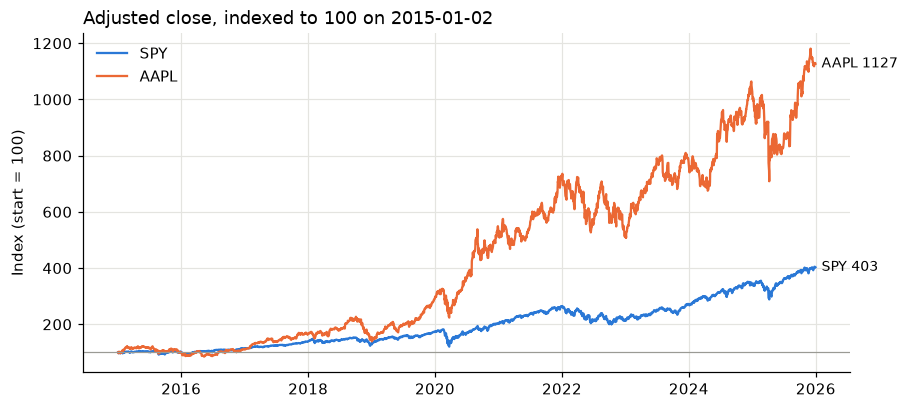

In [3]:
indexed = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(9, 4))
for col in indexed.columns:
    ax.plot(indexed.index, indexed[col], color=COLORS[col], label=col)
    ax.annotate(f"{col} {indexed[col].iloc[-1]:.0f}", (indexed.index[-1], indexed[col].iloc[-1]),
                xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
ax.axhline(100, color="#9a9a94", linewidth=0.8)
ax.set_title("Adjusted close, indexed to 100 on 2015-01-02", loc="left")
ax.set_ylabel("Index (start = 100)")
ax.legend(frameon=False, loc="upper left")
plt.show()

## 3. Rendimenti giornalieri

Rendimenti semplici e logaritmici sono quasi uguali quando sono piccoli (`log(1+r) ≈ r`). Guardiamo la differenza massima.

In [4]:
r_simple = simple_returns(prices).dropna()
r_log = log_returns(prices).dropna()
print("Max |simple - log|:", (r_simple - r_log).abs().max().round(4).to_dict())
r_simple.describe().round(4)

Max |simple - log|: {'SPY': 0.0065, 'AAPL': 0.0107}


Ticker,SPY,AAPL
count,2764.0000,2764.0000
mean,0.0006,0.0010
std,0.0112,0.0182
min,-0.1094,-0.1286
25%,-0.0037,-0.0073
50%,0.0006,0.0010
75%,0.0059,0.0100
max,0.1050,0.1533


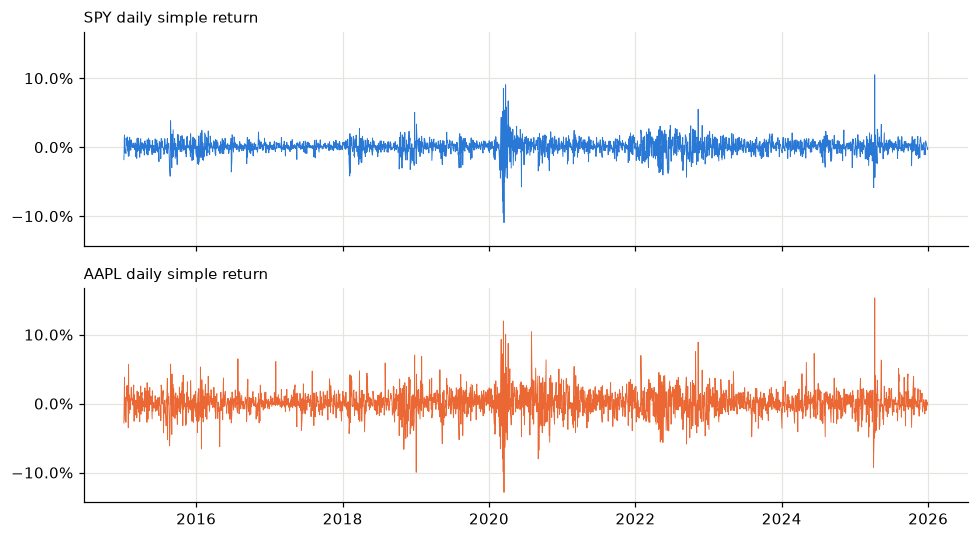

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, sharey=True)
for ax, col in zip(axes, r_simple.columns):
    ax.plot(r_simple.index, r_simple[col], color=COLORS[col], linewidth=0.6)
    ax.set_title(f"{col} daily simple return", loc="left", fontsize=10)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
fig.tight_layout()
plt.show()

La volatilità **non è costante**: si concentra a grappoli (marzo 2020, 2022, aprile 2025). Si chiama *volatility clustering* ed è il motivo per cui nel bootstrap (Fase 4) ricampioniamo **blocchi** di giorni e non giorni singoli.

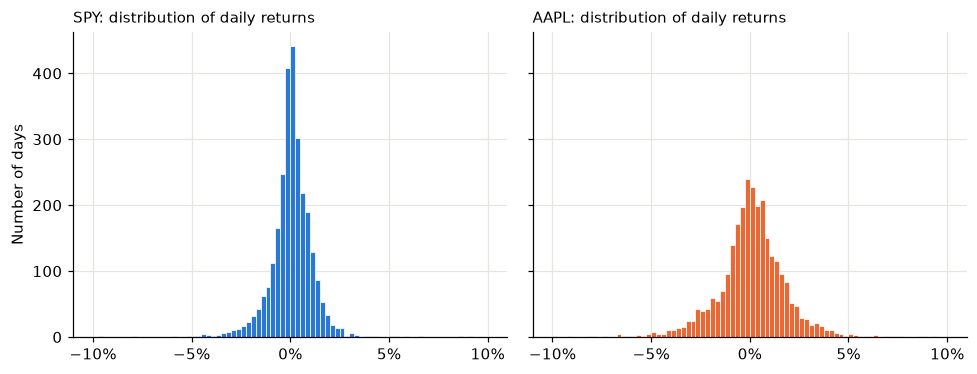

Excess kurtosis (normal = 0): {'SPY': 14.2, 'AAPL': 6.6}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
bins = np.linspace(-0.1, 0.1, 81)
for ax, col in zip(axes, r_simple.columns):
    ax.hist(r_simple[col], bins=bins, color=COLORS[col], edgecolor="white", linewidth=0.5)
    ax.set_title(f"{col}: distribution of daily returns", loc="left", fontsize=10)
    ax.set_xticks([-0.1, -0.05, 0, 0.05, 0.1])
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
axes[0].set_ylabel("Number of days")
fig.tight_layout()
plt.show()

print("Excess kurtosis (normal = 0):", r_simple.kurt().round(1).to_dict())

Curtosi molto sopra 0 = **code grasse**: i giorni estremi sono molto più frequenti di quanto direbbe una distribuzione normale. Per questo non basta guardare la volatilità: servono anche drawdown e bootstrap.

## Da ricordare: survivorship bias
Qui abbiamo scelto SPY e AAPL *oggi*, sapendo che AAPL è andata benissimo. Un test fatto solo su aziende sopravvissute (e vincenti) gonfia i risultati: le aziende fallite non compaiono più su Yahoo.